# Studies of random matrices their singular value decompositions

Construct some matrices from sampling their distributions and look at the impact of changing the distribution on the SVD. This mostly involves developing intuition for results from Random Matrix Theory.

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from scipy.stats import differential_entropy, gaussian_kde

## Some helper functions to generate matrices of interest

In [3]:
sv_bins = np.linspace(0, 10, 501)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
w_bins = np.linspace(-5, 5, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]


def generate_full_rank(d_n, mu=0, sigma=1):
    h = np.random.normal(loc=mu, scale=sigma, size=d_n * d_n)
    W_QK = h.reshape(d_n, d_n) / np.sqrt(d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w, _ = np.histogram(h, w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


def generate_low_rank(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K / np.sqrt(d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w, _ = np.histogram(W_QK.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


def average_curves(func, n_samp=10, **kwargs):
    results = [func(**kwargs) for _ in range(n_samp)]
    x_list, y_list, z_list = zip(*results)
    x_avg = torch.stack(x_list).mean(dim=0)
    y_avg = torch.stack(y_list).mean(dim=0)
    z_avg = torch.stack(z_list).mean(dim=0)
    return (x_avg, y_avg, z_avg)


def draw_trio(func, **kwargs):
    _, axes = plt.subplots(1, 3, figsize=(12, 3))
    sv, arr, spec = average_curves(func, **kwargs)

    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel("W")
    axes[0].set_ylabel("P(W)")

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("SV")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("SV")
    axes[2].set_ylabel("P(SV)")
    axes[2].set_yscale("log")

    plt.tight_layout()
    plt.show()

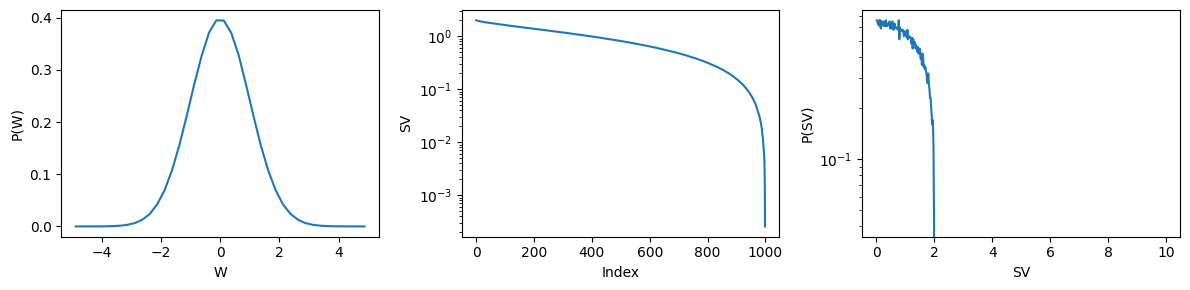

In [4]:
draw_trio(generate_full_rank, d_n=1000, n_samp=5)

## Singular value distributions and spectral densities

### Full rank - varying $\sigma$

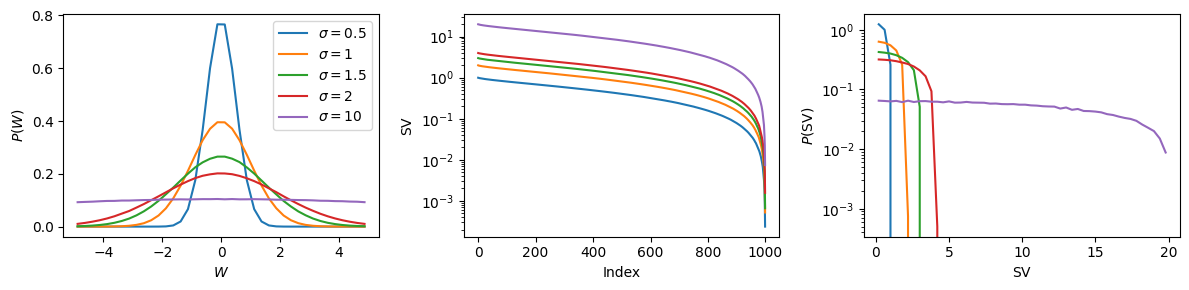

In [5]:
d_n = 1000
d_m = 500
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-5, 5, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

sv_bins = np.linspace(0, 20, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_full_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    sv, arr, spec = average_curves(generate_full_rank, d_n=d_n, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Low rank - varying $\sigma$ at fixed $d_n / d_m = 2$

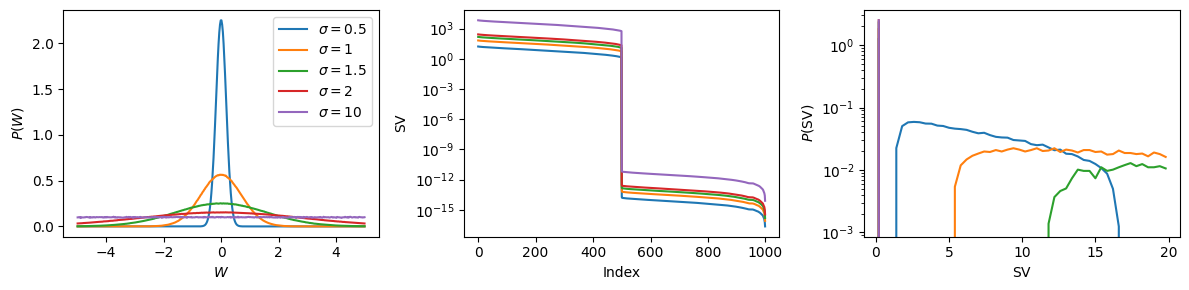

In [6]:
d_n = 1000
d_m = 500
w_bins = np.linspace(-5, 5, 401)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

_, axes = plt.subplots(1, 3, figsize=(12, 3))
h_low_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Low rank - $\sigma = 1$ varying $d_n / d_m = 0.1, 0.2, \cdots 1$

Also showing full rank. 

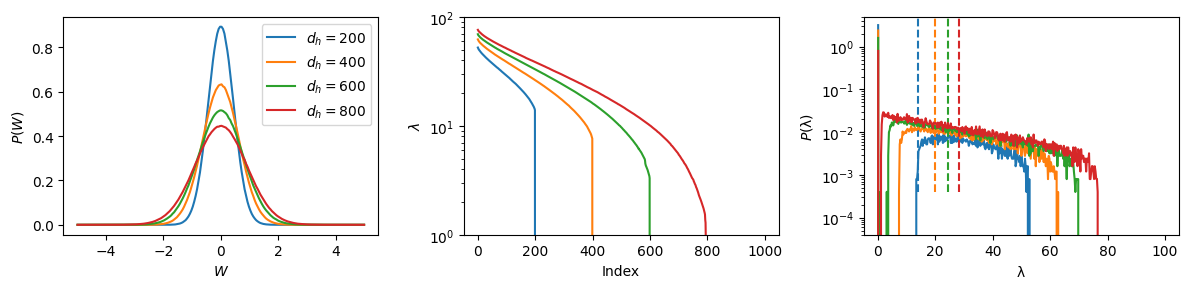

In [73]:
d_n = 1000
d_step = 200
sigma = 1
w_bins = np.linspace(-5, 5, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 100, 400)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))
sigma_empirical = []
for d_m in range(d_step, d_n + d_step - d_step, d_step):
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$d_h = {d_m}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()
    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\lambda$")
    axes[1].set_yscale("log")
    axes[1].set_ylim(bottom=1, top=100)
    line = axes[2].plot(sv_centers, spec)[0]
    color = line.get_color()
    # kde = gaussian_kde(sv)
    # axes[2].plot(sv_centers, kde(sv_centers))
    axes[2].set_xlabel("$\mathrm{\lambda}$")
    axes[2].set_ylabel("$P(\mathrm{\lambda})$")
    axes[2].set_yscale("log")
    axes[2].set_ylim(bottom=single_count_density * 0.01, top=5)
    vline1 = np.linspace(single_count_density * 0.1, 5, 20)
    # lm = [np.sqrt(d_m) * 2 * (1 - np.sqrt(d_m / d_n))for _ in vline1]
    # lp = [np.sqrt(d_m) * 2 * (1 + np.sqrt(d_m / d_n))for _ in vline1]
    lm = [np.sqrt(d_m) for _ in vline1]
    axes[2].plot(lm, vline1,'--',color=color)
    # axes[2].plot(lp, vline1,'--',color=color)
    # break
plt.tight_layout()
plt.show()

## Two Gaussians
Model is now $x ~ f N(0,1) + (1-f)N(\mu, \sigma)$
First we evaluate at fixed $f$, choosing $\mu ~0$ and $\sigma >> 1$. This has the effect of adding a nearly uniform component to the distribution but without the usual effects from the finite domain of the Uniform distribution.

In [8]:
def sample_mixture(
    d_n, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=2.0, f=0.5, binomial=False, device="cpu"
):
    n = d_n * d_n
    if binomial:
        n2 = int(
            torch.binomial(
                torch.tensor(n, dtype=torch.float32), torch.tensor(float(f))
            ).item()
        )
    else:
        n2 = int(f * n)
    n1 = n - n2
    dev = torch.device(device)
    samples1 = torch.normal(mu1, sigma1, size=(n1,), device=dev)
    samples2 = torch.normal(mu2, sigma2, size=(n2,), device=dev)

    samples = torch.cat([samples1, samples2])
    samples = samples[torch.randperm(n, device=dev)]
    _, S, _ = torch.linalg.svd(samples.reshape(d_n, d_n))
    P_w, _ = np.histogram(samples, w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

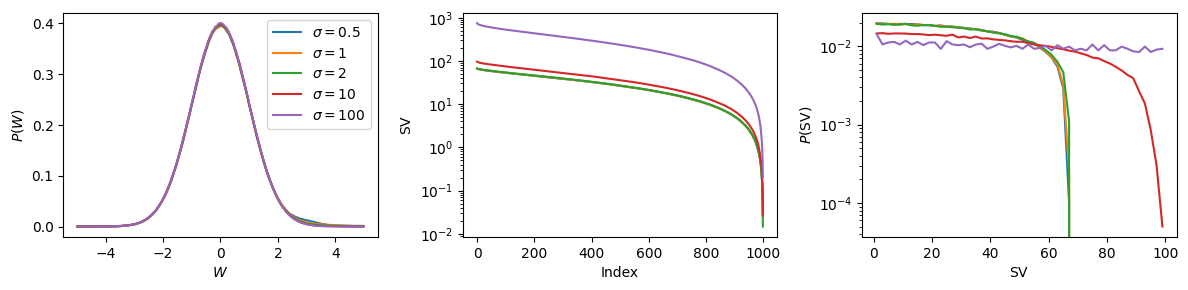

In [9]:
d_n = 1000
d_step = 200
w_bins = np.linspace(-5, 5, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 100, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))

for sigma in [0.5, 1, 2, 10, 100]:
    sv, arr, spec = average_curves(
        sample_mixture, d_n=d_n, mu2=3, sigma2=sigma, f=0.01, binomial=True
    )

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")
    # axes[1].set_xlim(left=0, right=10)

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

## Nested block structures
- Nesting recursively $A_{n+1}$ = $A_{n} \otimes A_{n}$
    - Dimension blows up quickly, matrices are $n^{2m} \times n^{2m}$
- Nesting with self: $W = A \otimes A \otimes \cdots A$, where $A$ is a single $n\times n$ matrix multiplied $m$ times.
- Nesting with a new matrix each time: $W = A_0 \otimes A_1 \otimes \cdots A_m$ where the $A_i$'s are separate random matrices


Simplification use $A_i = \mathbf{R}(\theta_i)$. Parameterize the matrix by random angles.


In [10]:
def generate_nested_blocks(d_h, n_h, nested=False):
    # A = torch.tensor(np.random.normal(size=(d_h, d_h)))
    theta = torch.rand(1) * 2 * math.pi
    c, s = torch.cos(theta), torch.sin(theta)
    A = torch.tensor([[c, -s], [s, c]])
    print(f"Theta 0: {theta.item():.2f}")
    # A = torch.tensor(np.arange(d_h*d_h).reshape(d_h,d_h))
    for idx in range(n_h):
        B = A
        if nested:
            # B = torch.tensor(np.random.normal(size=(d_h, d_h)))
            theta = torch.rand(1) * 2 * math.pi
            print(f"Theta {idx}: {theta.item():.2f}")

            c, s = torch.cos(theta), torch.sin(theta)
            A = torch.tensor([[c, -s], [s, c]])
        A = torch.kron(A, B)

    _, S, _ = torch.linalg.svd(A)
    P_w, _ = np.histogram(A.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


gnb = generate_nested_blocks(2, 3)

Theta 0: 2.85


In [11]:
# def generate_blocks(d_h, n_h, rotation=False, nested=False):
#     M = torch.tensor(np.random.normal(size=(d_h, d_h)))
#     A = torch.tensor(M)
#     for idx in range(n_h):
#         A = torch.kron(A, M)

#     _, S, _ = torch.linalg.svd(A)
#     P_w,_ = np.histogram(A.flatten(), w_bins, density = True)
#     P_s,_ = np.histogram(S, sv_bins, density = True)
#     return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)
# gnb = generate_nested_blocks(2, 3)

In [12]:
import matplotlib.pyplot as plt

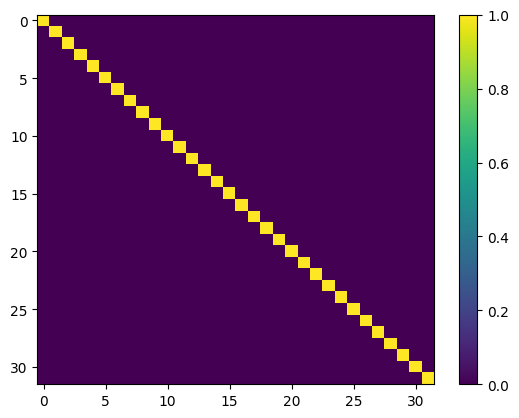

In [13]:
def generate_blocks(n_h, theta):
    theta = torch.tensor(theta)
    c, s = torch.cos(theta), torch.sin(theta)
    M = torch.tensor([[c, -s], [s, c]])
    A = M.detach().clone()
    for idx in range(n_h):
        A = torch.kron(A, M)
    return A


bd_mat = generate_blocks(4, 0)
# print(bd_mat.shape)
# print(bd_mat)
plt.imshow(bd_mat, cmap="viridis", aspect="auto")
plt.colorbar()

Theta 0: 0.34
Theta 0: 3.91
Theta 0: 0.61
Theta 0: 2.69
Theta 0: 5.29
Theta 0: 3.85
Theta 0: 1.63
Theta 0: 2.04
Theta 0: 0.93
Theta 0: 1.98
Theta 0: 0.61
Theta 0: 0.06
Theta 1: 4.37
Theta 2: 6.24
Theta 0: 2.45
Theta 0: 2.29
Theta 1: 1.43
Theta 2: 5.29
Theta 0: 2.15
Theta 0: 6.16
Theta 1: 5.22
Theta 2: 5.18
Theta 0: 2.60
Theta 0: 1.14
Theta 1: 4.08
Theta 2: 3.60
Theta 0: 3.71
Theta 0: 0.05
Theta 1: 2.95
Theta 2: 0.67
Theta 0: 3.56
Theta 0: 0.82
Theta 1: 5.24
Theta 2: 4.81
Theta 0: 0.89
Theta 0: 5.26
Theta 1: 5.69
Theta 2: 5.82
Theta 0: 0.83
Theta 0: 5.45
Theta 1: 3.24
Theta 2: 2.09
Theta 0: 0.24
Theta 0: 3.79
Theta 1: 5.75
Theta 2: 2.20
Theta 0: 0.21
Theta 0: 2.88
Theta 1: 0.63
Theta 2: 2.94


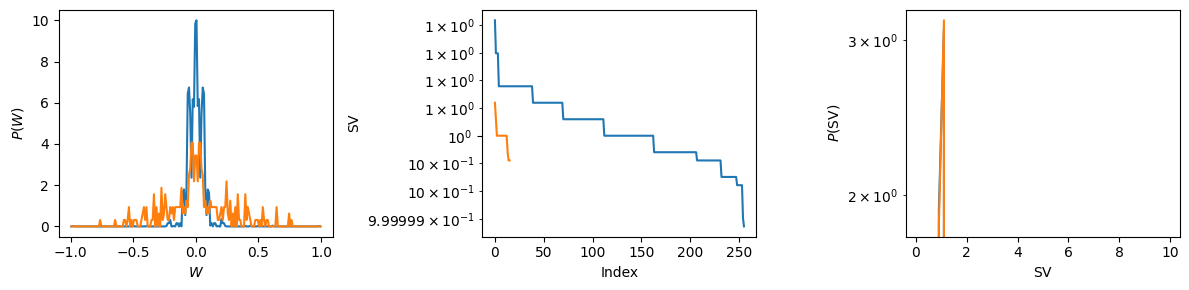

In [14]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-1, 1, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 10, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
n_h = 3
for tf in [False, True]:
    sv, arr, spec = average_curves(generate_nested_blocks, d_h=2, n_h=n_h, nested=tf)

    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")
    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Using $SO(n)$ symmetry
$\mathbf{W} = \sum_g A_g \mathbf{T}_g$ where $\mathbf{T}$ are the generators of $SO(n)$, $n\times n$ anti-symmetric matrices. There are $n(n-1)/2$ generators.

In [15]:
def so_n_generators(n):
    """Generate all basis elements for the Lie algebra so(n)"""
    generators = []

    for i in range(n):
        for j in range(i + 1, n):
            L = torch.zeros(n, n)
            L[i, j] = 1
            L[j, i] = -1
            generators.append(L)

    return generators


def random_so_n_element(n):
    """Create random antisymmetric matrix as linear combination of generators"""
    generators = so_n_generators(n)
    d = len(generators)  # n(n-1)/2

    # Random coefficients
    A = torch.randn(d)

    # Linear combination
    M = torch.zeros(n, n)
    for i, coeff in enumerate(A):
        M += coeff * generators[i]

    return M, A, generators


# Example
n = 4
M, coeffs, gens = random_so_n_element(n)

print(f"Random so({n}) element:")
print(M)
print(f"\nCoefficients shape: {coeffs.shape}")
print(f"Is antisymmetric? {torch.allclose(M, -M.T)}")


def generate_so_n(d_n):
    M, _, _ = random_so_n_element(n=d_n)
    _, S, _ = torch.linalg.svd(M)
    P_w, _ = np.histogram(M.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

Random so(4) element:
tensor([[ 0.0000, -2.2895, -0.1787,  0.9929],
        [ 2.2895,  0.0000, -1.2793,  0.3497],
        [ 0.1787,  1.2793,  0.0000, -1.2379],
        [-0.9929, -0.3497,  1.2379,  0.0000]])

Coefficients shape: torch.Size([6])
Is antisymmetric? True


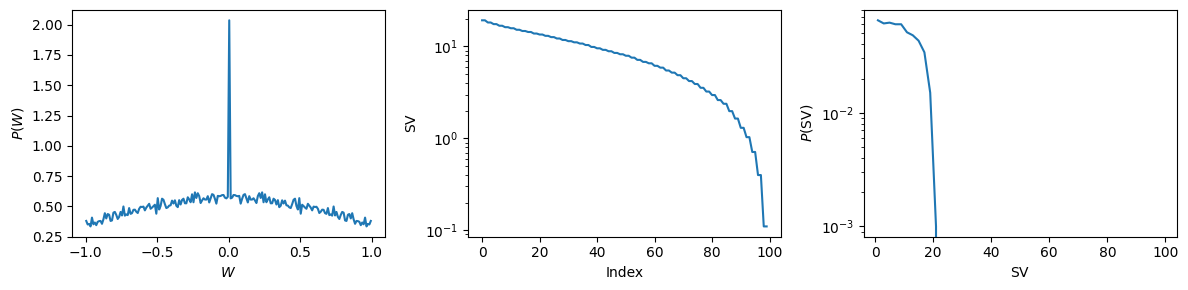

In [16]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-1, 1, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 100, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
for tf in [1]:
    sv, arr, spec = average_curves(generate_so_n, d_n=100)
    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

In [17]:
def generate_low_rank_2(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K / np.sqrt(d_n)
    W_QK = W_QK.flatten()
    sigma = np.std(W_QK)
    entropy = differential_entropy(W_QK)
    return sigma, entropy

In [18]:
d_model = 1000
n_steps = 10
results = [generate_low_rank_2(d_model,d_m) for d_m in range(0,d_model,n_steps)]
x_vals =np.array([d_m for d_m in range(0,d_model,n_steps)])
sig, ent = zip(*results)

/opt/anaconda3/envs/llm-work/lib/python3.11/site-packages/scipy/stats/_entropy.py:381: RuntimeWarning: divide by zero encountered in log
  logs = xp.log(n/(2*m) * differences)


/var/folders/_5/w5f7n1zx5t521cn85gjbd2400000gn/T/ipykernel_35963/2775538812.py:4: RuntimeWarning: divide by zero encountered in log
  plt.plot(x_vals, 0.5*(np.log(2*np.pi*np.e*x_vals/d_model)), '--', label=r'$\frac{1}{2}\ln 2\pi e d/d_{\text{model}}$')


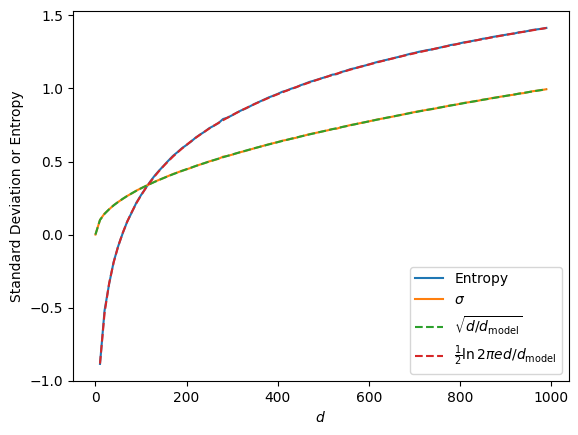

In [19]:
plt.plot(x_vals, ent, label='Entropy')
plt.plot(x_vals, sig, label=r'$\sigma$')
plt.plot(x_vals, np.sqrt(x_vals/d_model), '--', label=r'$\sqrt{d/d_{\text{model}}}$')
plt.plot(x_vals, 0.5*(np.log(2*np.pi*np.e*x_vals/d_model)), '--', label=r'$\frac{1}{2}\ln 2\pi e d/d_{\text{model}}$')
plt.xlabel('$d$')
plt.ylabel('Standard Deviation or Entropy')
plt.legend()

In [20]:
dmax = 1000
ranks = [10, 100, 200, 400, 600, 800]
tvals = np.linspace(0,5,101)
for r in ranks:
    yvals = marchenko_pastur_density(tvals, d=dmax, r=r)
    plt.plot(tvals,yvals)
plt.yscale('log')

NameError: name 'marchenko_pastur_density' is not defined

In [ ]:
import numpy as np

def marchenko_pastur_density(s, d, r):
    # The key: each column of A and B contributes independently # Variance of (AB^T)_ij before scaling is r (sum of r products) # After /sqrt(d), variance is r/d per element # But for SVD, we care about W^T W eigenvalues # The correct form: treat as if drawing from two independent # d x r matrices, giving effective variance = 1 per entry, # but total contribution scales as sqrt(d) not sqrt(r)
    gamma = r / d
    
    # Corrected: singular values scale like sqrt(d), not sqrt(r)
    s_min = np.sqrt(d) * (1 - np.sqrt(gamma))
    s_max = np.sqrt(d) * (1 + np.sqrt(gamma))
    
    s = np.asarray(s)
    rho = np.zeros_like(s, dtype=float)
    
    mask = (s >= s_min) & (s <= s_max)
    s_masked = s[mask]
    
    rho[mask] = (1 / (np.pi * d)) * \
                np.sqrt((s_max**2 - s_masked**2) * (s_masked**2 - s_min**2)) / s_masked
    
    return rho

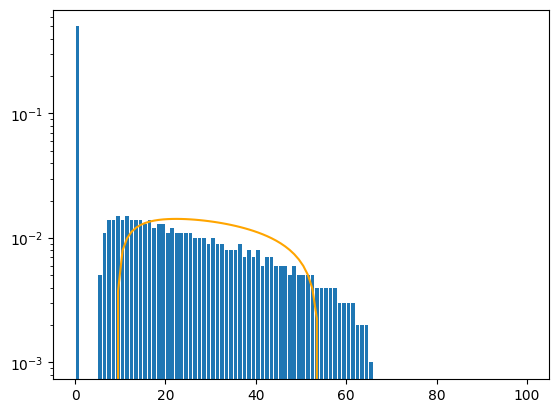

In [ ]:
dmax = 1000
d_h = 500
sv, arr, spec = average_curves(generate_low_rank, d_n=dmax,d_m=d_h, sigma=1, n_samp=20)
xbins = np.linspace(0,100,101)
xcenters = 0.5*(xbins[:-1] + xbins[1:])
hist, _ = np.histogram(sv, bins=xbins, density=True)
yvals = marchenko_pastur_density(xcenters, d=dmax, r=d_h)
plt.bar((xbins[:-1]+xbins[1:])*0.5,hist)
plt.yscale("log")
plt.plot(xcenters, yvals, c='orange')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_W_singulars_vs_theory(r, d, n_trials=1, bins=60, seed=None):
    """
    Simulate W = A^T B / sqrt(d) with A,B ~ N(0,1) iid of shape (r, d).
    Plot histogram of nonzero singular values (scaled by sqrt(r)) and overlay
    theoretical quarter-circle density on [0,2].
    Also plot histogram of squared singular values / r and overlay MP(c=1) density on [0,4].

    Parameters
    ----------
    r : int
        number of rows of A and B (rank <= r).
    d : int
        number of columns of A and B (d >= r typically).
    n_trials : int
        number of independent samples to aggregate (increase for smoother histogram).
    bins : int
        histogram bins.
    seed : int or None
        RNG seed for reproducibility.
    """
    rng = np.random.default_rng(seed)

    all_scaled_svs = []    # will store sigma / sqrt(r)
    all_lambda = []        # will store sigma^2 / r

    for t in range(n_trials):
        A = rng.standard_normal((r, d))
        B = rng.standard_normal((r, d))
        W = (A.T @ B) / np.sqrt(d)   # d x d, rank <= r
        sv = np.linalg.svd(W, compute_uv=False)  # length d, last d-r are zeros
        sv_nonzero = sv[:r]  # take the top r (nonzero) singular values (sorted desc by numpy)
        all_scaled_svs.append(sv_nonzero / np.sqrt(r))
        all_lambda.append((sv_nonzero**2) / r)

    all_scaled_svs = np.concatenate(all_scaled_svs)
    all_lambda = np.concatenate(all_lambda)

    # Theoretical quarter-circle density for singular values s in [0,2]
    xs = np.linspace(0, 2, 400)
    quarter_circle = (1.0 / np.pi) * np.sqrt(np.maximum(0.0, 4.0 - xs**2))

    # Theoretical MP(c=1) density for lambda in (0,4]
    lam = np.linspace(1e-8, 4.0, 400)
    mp_density = (1.0 / (2.0 * np.pi * lam)) * np.sqrt(np.maximum(0.0, 4.0 * lam - lam**2))

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (A) singular values scaled by sqrt(r)
    axes[0].hist(all_scaled_svs, bins=bins, density=True, alpha=0.6, label='empirical (scaled by sqrt(r))')
    axes[0].plot(xs, quarter_circle, lw=2, label='quarter-circle (1/π)√(4-x^2), x∈[0,2]')
    axes[0].set_xlabel('σ / sqrt(r)')
    axes[0].set_ylabel('density')
    axes[0].set_title(f'Singular values (nonzero) scaled by sqrt(r) — r={r}, d={d}')
    axes[0].legend()

    # (B) squared singular values / r vs MP(c=1)
    axes[1].hist(all_lambda, bins=bins, density=True, alpha=0.6, label='empirical (σ^2 / r)')
    axes[1].plot(lam, mp_density, lw=2, label='Marchenko–Pastur (c=1)')
    axes[1].set_xlabel('σ^2 / r')
    axes[1].set_ylabel('density')
    axes[1].set_title('Squared singular values normalized by r')
    axes[1].legend()
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_W_singulars_vs_theory(r=200, d=2000, n_trials=3, bins=80, seed=123)

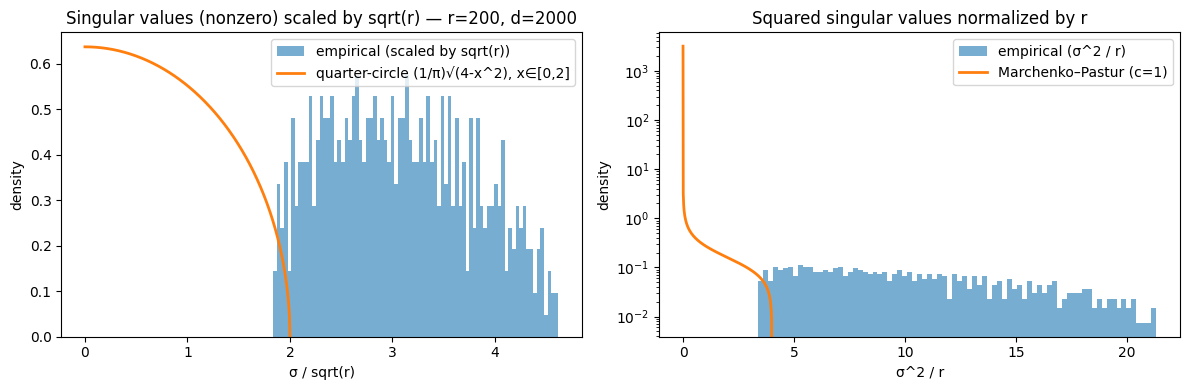

In [ ]:
plot_W_singulars_vs_theory(r=200, d=2000, n_trials=3, bins=80, seed=123)